## Context (before analysis)
- There's no explanation in the logic behind the existing segmentation in the dataset. Why is a player called "Minnow", "Dolphin", "Whale".
- Besides, the "Game Genre" hasn't been utilized in understanding segmentation of players regarding engagement and monetization, it is assumed that as "game genre" as contextual data, player behavioral profiles may diverge.
- Therefore, key research question: 
1. **What player behavioral profiles emerge when engagement, monetization, and game genre are considered together?**
2. **Does game genres help describe the composition of different behavioral dimensions (engagement + monetization)?** 

# Executive Summary (after analysis)

- Player segmentation revealed four similarly sized behavioral profiles, but monetization was concentrated among high-value players rather than strongly aligned with engagement. 
- A substantial Low Engagement–High Monetization group accounted for more observed revenue than the High Engagement–High Monetization group. 
- Genre composition was broadly similar across segments, while the relative revenue contribution of behavioral profiles varied considerably by genre.

Based on these findings, next question arises: **"What behavioral factors distinguish high-value players from lower-value players?"**

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/game_data_clean.csv")

In [5]:
segmentation_df = df[
    ["UserID",
     "SessionCount",
     "AverageSessionLength",
     "InAppPurchaseAmount",
     "FirstPurchaseDaysAfterInstall",
     "GameGenre",
     "SpendingSegment"

    ]
].copy()

segmentation_df.shape
segmentation_df.head()

,UserID,SessionCount,AverageSessionLength,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,GameGenre,SpendingSegment
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,9,12.83,11.40,28.0,Battle Royale,Minnow
1,7c9e413c-ecca-45f2-a780-2826a07952a2,11,19.39,6.37,18.0,Action RPG,Minnow
2,fd61e419-1a92-4f43-a8c7-135842ad328a,9,8.87,15.81,30.0,Fighting,Minnow
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,12,19.56,13.49,9.0,Racing,Minnow
4,aa7eec14-4846-47b9-b879-9c98038cda04,10,15.23,10.86,15.0,Battle Royale,Minnow


## Define Objective

The objective is to identify player profiles based on engagement and
monetization behavior, and then examine how these profiles are distributed across game genres.

The existing SpendingSegment variable is retained for comparison but
is not used to create the primary behavioral segmentation.

In [6]:
segmentation_df[
    [
        "SessionCount",
        "AverageSessionLength",
        "InAppPurchaseAmount"
    ]
].describe()

,SessionCount,AverageSessionLength,InAppPurchaseAmount
count,3024.000000,3024.000000,2888.000000
mean,10.074735,20.073978,102.582864
std,3.115863,8.585208,454.339708
min,1.000000,5.010000,0.000000
25%,8.000000,12.680000,5.987500
50%,10.000000,20.315000,11.975000
75%,12.000000,27.420000,17.762500
max,22.000000,34.990000,4964.450000


In [7]:
segmentation_df[
    [
        "SessionCount",
        "AverageSessionLength",
        "InAppPurchaseAmount"
    ]
].quantile([0.25, 0.5, 0.75, 0.90, 0.95])

,SessionCount,AverageSessionLength,InAppPurchaseAmount
0.25,8.0,12.680,5.9875
0.50,10.0,20.315,11.9750
0.75,12.0,27.420,17.7625
0.90,14.0,31.750,214.5760
0.95,15.0,33.320,375.0155


## Create Engagment Score

In [13]:
# Calculate engagement score using standardization: 1) SessionCount, 2) AverageSessionLength

segmentation_df["SessionCount_Z"] = (
    segmentation_df["SessionCount"]
    - segmentation_df["SessionCount"].mean()
) / segmentation_df["SessionCount"].std()

segmentation_df["SessionLength_Z"] = (
    segmentation_df["AverageSessionLength"]
    - segmentation_df["AverageSessionLength"].mean()
) / segmentation_df["AverageSessionLength"].std()

segmentation_df[
    ["SessionCount_Z", "SessionLength_Z"]
    ].describe()

,SessionCount_Z,SessionLength_Z
count,3.024000e+03,3.024000e+03
mean,1.562536e-16,1.656523e-16
std,1.000000e+00,1.000000e+00
min,-2.912431e+00,-1.754643e+00
25%,-6.658622e-01,-8.612462e-01
50%,-2.398547e-02,2.807408e-02
75%,6.178912e-01,8.556603e-01
max,3.827275e+00,1.737409e+00


In [ ]:
segmentation_df["EngagementScore"] = (
    segmentation_df["SessionCount_Z"] +
    segmentation_df["SessionLength_Z"]
) / 2
# Analytical rule: Both variables share the same weight in the calculation, 
# meaning that they assumingly have the same importance in understanding engagement levels.

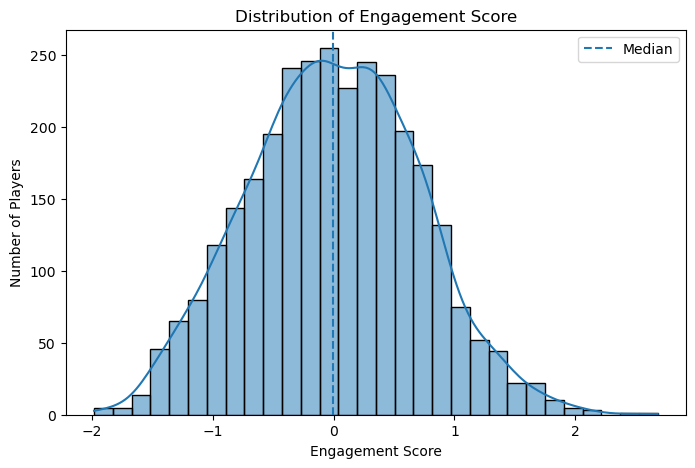

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    segmentation_df["EngagementScore"],
    bins=30,
    kde=True
)

plt.axvline(
    segmentation_df["EngagementScore"].median(),
    linestyle="--",
    label="Median"
)

plt.title("Distribution of Engagement Score")
plt.xlabel("Engagement Score")
plt.ylabel("Number of Players")
plt.legend()
plt.show()

In [19]:
segmentation_df["EngagementScore"].quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90]
)

0.10   -0.929133
0.25   -0.481054
0.50   -0.003117
0.75    0.491915
0.90    0.866028
Name: EngagementScore, dtype: float64

## Transform Revenue

In [ ]:
# Calculate monetization variable
segmentation_df["LogRevenue"] = np.log1p(
    segmentation_df["InAppPurchaseAmount"]
)
segmentation_df[
    ["InAppPurchaseAmount", "LogRevenue"]
].describe()

,InAppPurchaseAmount,LogRevenue
count,2888.000000,2888.000000
mean,102.582864,2.736908
std,454.339708,1.485200
min,0.000000,0.000000
25%,5.987500,1.944123
50%,11.975000,2.563024
75%,17.762500,2.931860
max,4964.450000,8.510259


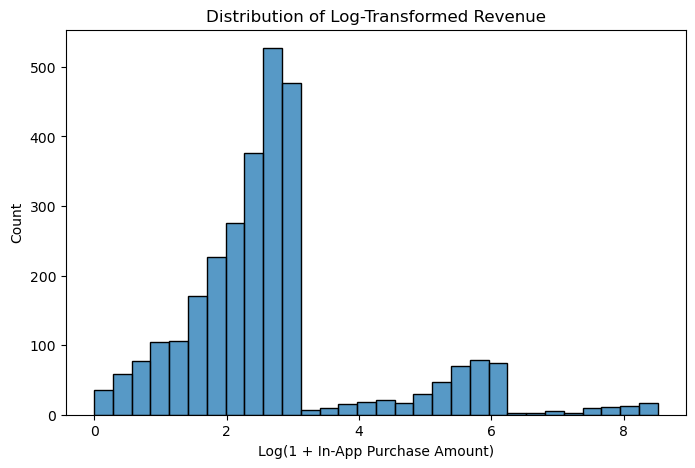

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(segmentation_df["LogRevenue"].dropna(), bins=30)
plt.title("Distribution of Log-Transformed Revenue")
plt.xlabel("Log(1 + In-App Purchase Amount)")
plt.show()

In [23]:
segmentation_df["InAppPurchaseAmount"].isna().sum()
segmentation_df["InAppPurchaseAmount"].value_counts(dropna=False).head()

InAppPurchaseAmount
NaN      136
11.72      7
12.58      7
0.92       6
8.65       6
Name: count, dtype: int64

## Define thresholds & analytical population

In [ ]:
# Decide high/low thresholds
engagement_threshold = segmentation_df["EngagementScore"].median()
revenue_threshold = segmentation_df["LogRevenue"].median()

print("Engagement threshold:", engagement_threshold)
print("Revenue threshold:", revenue_threshold)

Engagement threshold: -0.003117406995278932
Revenue threshold: 2.563024354802148


In [ ]:
# Define analytical population

behavior_df = segmentation_df.dropna(
    subset=[
        "EngagementScore",
        "LogRevenue",
        "GameGenre"
    ]
).copy()

print("Players in segmentation:", len(behavior_df))
print("Excluded players:", len(segmentation_df) - len(behavior_df))
print(f"We do not have sufficient information to classify the excluded players' monetization behavior.")

Players in segmentation: 2831
Excluded players: 193
We do not have sufficient information to classify their monetization behavior.


## Create Behavioral Segments

In [35]:
# Based on the defined thresholds and population, there will be 4 behavioral segments.

engagement_threshold = behavior_df["EngagementScore"].median()
revenue_threshold = behavior_df["LogRevenue"].median()


def classify_player(row):
    high_engagement = row["EngagementScore"] >= engagement_threshold
    high_monetization = row["LogRevenue"] >= revenue_threshold

    if high_engagement and high_monetization:
        return "High Engagement - High Monetization"
    elif high_engagement and not high_monetization:
        return "High Engagement - Low Monetization"
    elif not high_engagement and high_monetization:
        return "Low Engagement - High Monetization"
    else:
        return "Low Engagement - Low Monetization"

behavior_df["BehavioralSegment"] = behavior_df.apply(
    classify_player,
    axis=1
)

## Validate segmentation

In [ ]:
segment_validation = (
    behavior_df
    .groupby("BehavioralSegment")
    .agg(
        Players=("UserID", "count"),
        AvgEngagement=("EngagementScore", "mean"),
        AvgRevenue=("InAppPurchaseAmount", "mean"),
        MedianRevenue=("InAppPurchaseAmount", "median")
    )
    .reset_index()
)

segment_validation
# The low-low group spends even more than the high-low group.

,BehavioralSegment,Players,AvgEngagement,AvgRevenue,MedianRevenue
0,High Engagement - High Monetization,718,0.571167,181.013036,17.690
1,High Engagement - Low Monetization,698,0.568076,5.746032,5.600
2,Low Engagement - High Monetization,698,-0.567357,217.205301,17.795
3,Low Engagement - Low Monetization,717,-0.576611,6.156332,6.200


## Profile segments & Add other variables
- SpendingSegment
- GameGenre
- Revenue

In [37]:
segment_profile = (
    behavior_df
    .groupby("BehavioralSegment")
    .agg(
        Players=("UserID", "count"),
        Revenue=("InAppPurchaseAmount", "sum"),
        MedianRevenue=("InAppPurchaseAmount", "median"),
        AvgSessions=("SessionCount", "mean"),
        AvgSessionLength=("AverageSessionLength", "mean")
    )
    .reset_index()
)

segment_profile["PlayerShare"] = (
    segment_profile["Players"]
    / segment_profile["Players"].sum()*100
)

segment_profile["RevenueShare"] = (
    segment_profile["Revenue"]
    / segment_profile["Revenue"].sum()*100
)

segment_profile

,BehavioralSegment,Players,Revenue,MedianRevenue,AvgSessions,AvgSessionLength,PlayerShare,RevenueShare
0,High Engagement - High Monetization,718,129967.36,17.690,11.688022,25.436031,25.362063,44.816102
1,High Engagement - Low Monetization,698,4010.73,5.600,11.643266,25.506275,24.655599,1.383003
2,Low Engagement - High Monetization,698,151609.30,17.795,8.469914,14.754026,24.655599,52.278802
3,Low Engagement - Low Monetization,717,4414.09,6.200,8.423989,14.721660,25.326740,1.522092


In [38]:
# Cross check "SpendingSegment" with "BehavioralSegment"
# In each behavioral segment, how many percentages do Minnow/Dolphin/Whale account for?

segment_spending_mix = pd.crosstab(
    behavior_df["BehavioralSegment"],
    behavior_df["SpendingSegment"],
    normalize="index"
) * 100

segment_spending_mix

SpendingSegment,Dolphin,Minnow,Whale
BehavioralSegment,,,
High Engagement - High Monetization,27.298050,68.802228,3.899721
High Engagement - Low Monetization,0.000000,100.000000,0.000000
Low Engagement - High Monetization,26.790831,68.338109,4.871060
Low Engagement - Low Monetization,0.000000,100.000000,0.000000


In [40]:
# Cross check "GameGenre" with "BehavioralSegment"
# Within each behavioral segment, what percentage of players belong to each genre?

genre_mix = pd.crosstab(
    behavior_df["BehavioralSegment"],
    behavior_df["GameGenre"],
    normalize="index"
) * 100

genre_mix

GameGenre,Action RPG,Adventure,Battle Royale,Card,Casual,Fighting,MMORPG,MOBA,Puzzle,Racing,Role Playing,Sandbox,Simulation,Sports,Strategy
BehavioralSegment,,,,,,,,,,,,,,,
High Engagement - High Monetization,6.128134,6.685237,6.406685,7.103064,7.520891,5.988858,8.077994,5.153203,6.963788,5.571031,7.242340,7.381616,7.381616,6.545961,5.849582
High Engagement - Low Monetization,6.876791,5.873926,6.876791,7.879656,5.587393,5.730659,5.300860,7.593123,6.590258,5.587393,6.876791,6.733524,8.022923,7.879656,6.590258
Low Engagement - High Monetization,5.730659,4.727794,6.446991,6.733524,7.879656,6.446991,5.587393,6.876791,8.595989,7.879656,4.727794,7.163324,7.593123,7.163324,6.446991
Low Engagement - Low Monetization,7.252441,5.578801,5.578801,5.857741,7.531381,6.136681,7.531381,4.881450,5.439331,6.694561,6.973501,7.949791,6.694561,8.089261,7.810321


In [41]:
# Revere the check
# In one genre, how does the player composition look like?
genre_segment_mix = pd.crosstab(
    behavior_df["GameGenre"],
    behavior_df["BehavioralSegment"],
    normalize="index"
) * 100

genre_segment_mix

BehavioralSegment,High Engagement - High Monetization,High Engagement - Low Monetization,Low Engagement - High Monetization,Low Engagement - Low Monetization
GameGenre,,,,
Action RPG,23.913043,26.086957,21.739130,28.260870
Adventure,29.629630,25.308642,20.370370,24.691358
Battle Royale,25.698324,26.815642,25.139665,22.346369
Card,26.153846,28.205128,24.102564,21.538462
Casual,26.732673,19.306931,27.227723,26.732673
Fighting,25.000000,23.255814,26.162791,25.581395
MMORPG,30.851064,19.680851,20.744681,28.723404
MOBA,21.387283,30.635838,27.745665,20.231214
Puzzle,25.641026,23.589744,30.769231,20.000000


In [ ]:
# Revenue by Genre following the Behavioral Segment
# Within each genre, which behavioral player type contributes the observed revenue?
genre_segment_revenue = (
    behavior_df
    .groupby(["GameGenre", "BehavioralSegment"])
    .agg(
        Players=("UserID", "count"),
        Revenue=("InAppPurchaseAmount", "sum")
    )
    .reset_index()
)

genre_segment_revenue["RevenueShareWithinGenre"] = (
    genre_segment_revenue["Revenue"]
    /
    genre_segment_revenue.groupby("GameGenre")["Revenue"].transform("sum")*100
)

genre_segment_revenue

,GameGenre,BehavioralSegment,Players,Revenue,RevenueShareWithinGenre
0,Action RPG,High Engagement - High Monetization,44,5890.69,50.836328
1,Action RPG,High Engagement - Low Monetization,48,310.21,2.677095
2,Action RPG,Low Engagement - High Monetization,40,5087.03,43.900787
3,Action RPG,Low Engagement - Low Monetization,52,299.63,2.585790
4,Adventure,High Engagement - High Monetization,48,11746.55,74.759458
5,Adventure,High Engagement - Low Monetization,41,215.62,1.372287
6,Adventure,Low Engagement - High Monetization,33,3511.74,22.350033
7,Adventure,Low Engagement - Low Monetization,40,238.55,1.518222
8,Battle Royale,High Engagement - High Monetization,46,13732.35,48.962288
9,Battle Royale,High Engagement - Low Monetization,48,282.97,1.008921


### Visualizations

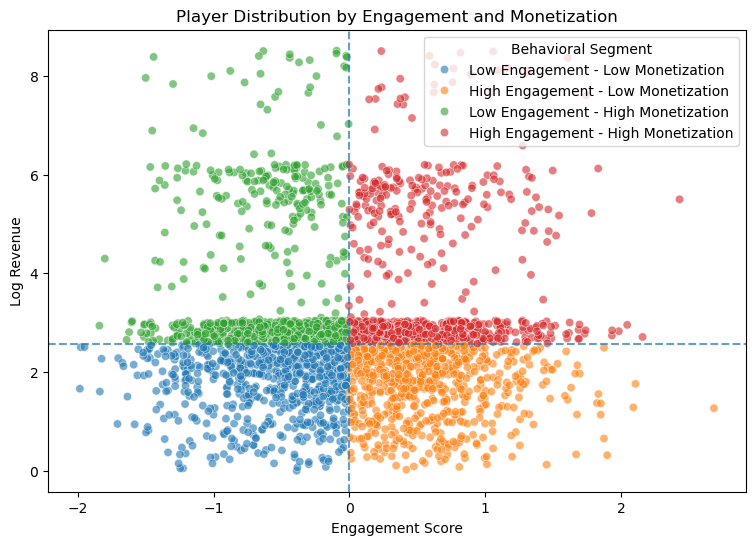

In [48]:
# Engagement x Monetization

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=behavior_df,
    x="EngagementScore",
    y="LogRevenue",
    hue="BehavioralSegment",
    alpha=0.6
)

plt.axvline(
    behavior_df["EngagementScore"].median(),
    linestyle="--",
    alpha=0.7
)

plt.axhline(
    behavior_df["LogRevenue"].median(),
    linestyle="--",
    alpha=0.7
)

plt.title("Player Distribution by Engagement and Monetization")
plt.xlabel("Engagement Score")
plt.ylabel("Log Revenue")
plt.legend(title="Behavioral Segment")
plt.show()

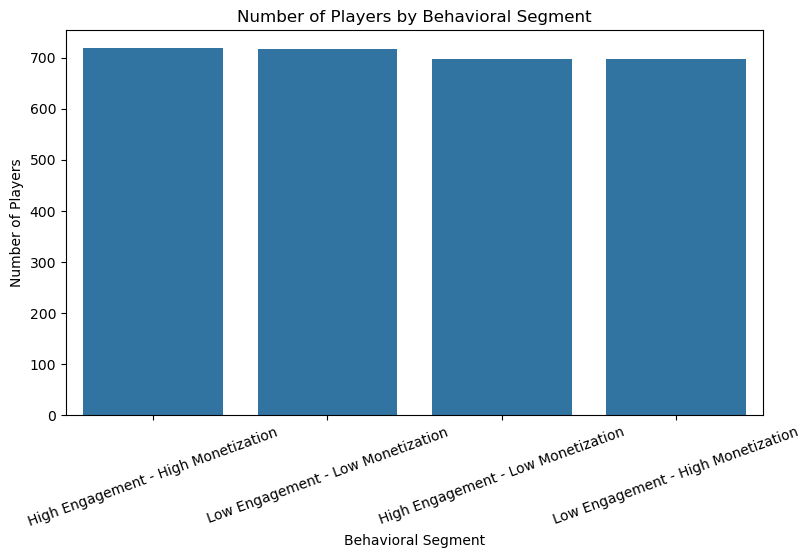

In [49]:
# Behavioral Segment Size

segment_counts = (
    behavior_df["BehavioralSegment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["BehavioralSegment", "Players"]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_counts,
    x="BehavioralSegment",
    y="Players"
)

plt.title("Number of Players by Behavioral Segment")
plt.xlabel("Behavioral Segment")
plt.ylabel("Number of Players")
plt.xticks(rotation=20)
plt.show()

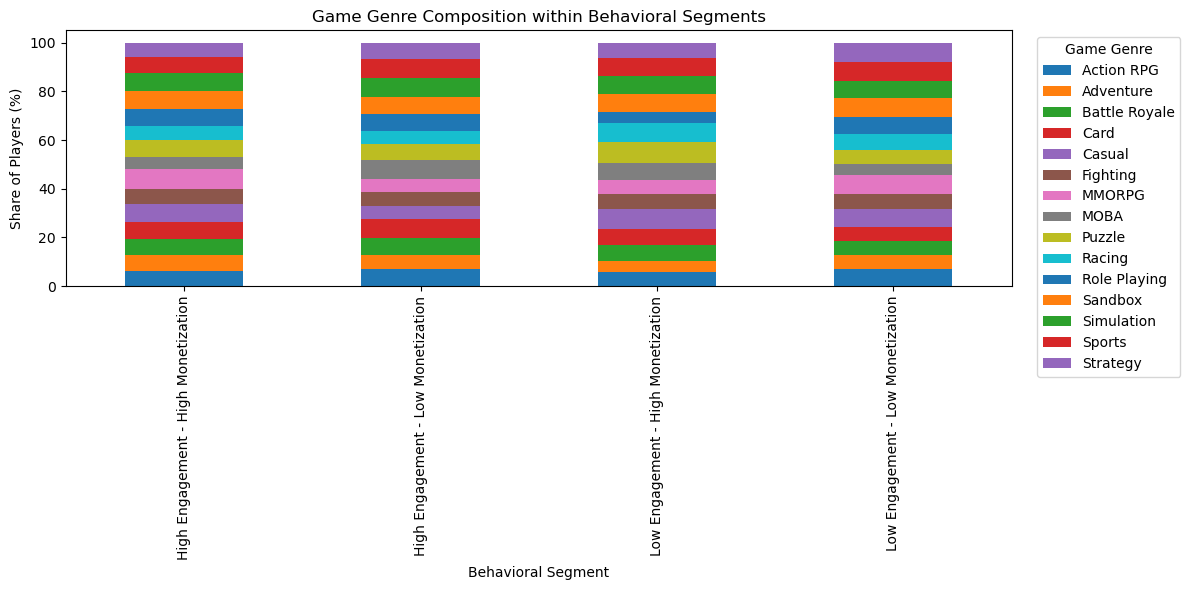

In [50]:
# GameGenre Composition by Behavioral Segment
genre_mix.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Game Genre Composition within Behavioral Segments")
plt.xlabel("Behavioral Segment")
plt.ylabel("Share of Players (%)")
plt.legend(
    title="Game Genre",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

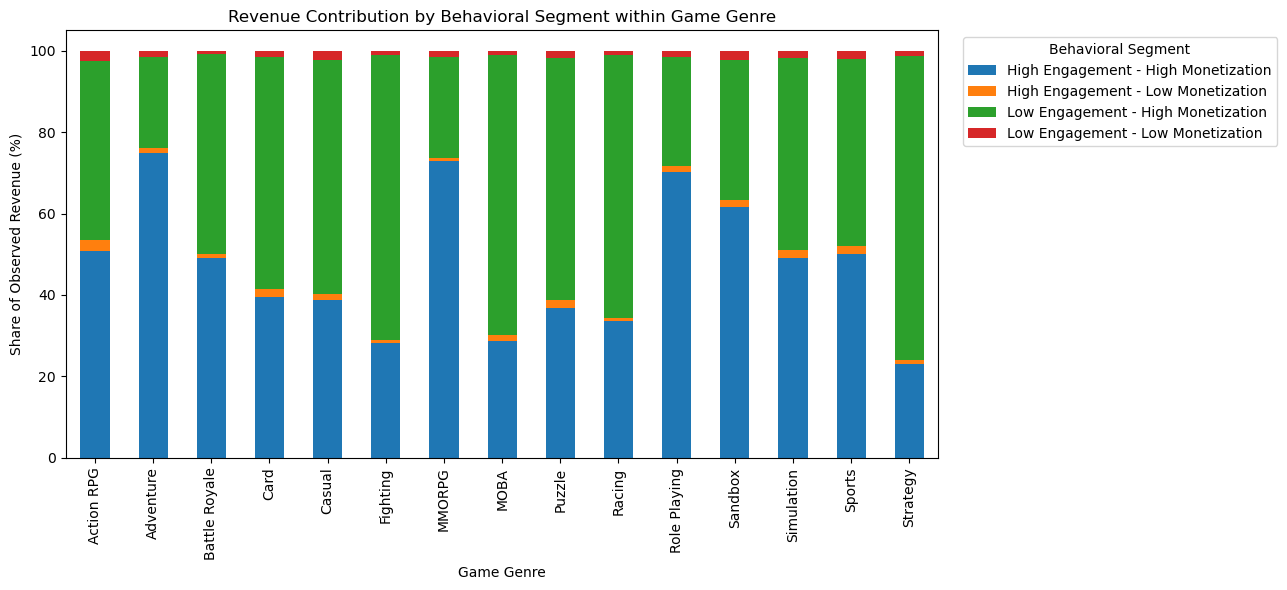

In [51]:
# Revenue Contribution within Genre
revenue_mix = genre_segment_revenue.pivot(
    index="GameGenre",
    columns="BehavioralSegment",
    values="RevenueShareWithinGenre"
).fillna(0)

revenue_mix.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 6)
)

plt.title("Revenue Contribution by Behavioral Segment within Game Genre")
plt.xlabel("Game Genre")
plt.ylabel("Share of Observed Revenue (%)")
plt.legend(
    title="Behavioral Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Key findings:

### 1. Behavioral Segments
- The player base is almost evenly divided across the four rule-based behavioral profiles, with each segment representing approximately one-quarter of players. 
- There is a substantial group of highly engaged but relatively low-monetizing players, as well as a substantial group of low-engagement but relatively high-monetizing players. 

> **Engagement and monetization are not simply moving together.**

### 2. Observed Revenue Share
- The two high-monetization segments together account for about 50% of players but approximately 97.1% of observed revenue. More specifically, the Low Engagement – High Monetization segment contributes slightly more observed revenue than the High Engagement – High Monetization segment.

> **Higher engagement is not necessarily associated with higher monetization in this dataset.**

### 3. Game Genres x Behavioral Segments
- The overall genre composition of the four segments is fairly similar.

> **No single genre dominates one behavioral segment to the extent that we could describe a segment as belonging to a particular genre.**

- Nevertheless, the High Engagement–High Monetization segment has relatively high representation in MMORPG, Sandbox, Simulation and Casual, while the Low Engagement–High Monetization segment has relatively high representation in Puzzle, Racing, Simulation and Casual.

### 4. Within each game genre
- Across genres, the majority of observed revenue comes from the two high-monetization behavioral segments. But the relative contribution of the two high-monetization groups differs substantially by genre.
- For some genres, observed revenue is predominantly associated with players who are both highly engaged and highly monetizing. In others, a much larger share of revenue comes from players who are relatively less engaged but highly monetizing.

